In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    # Data Augmentation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


In [ ]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Comptia/FaceDetectionUsingCNN',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Comptia/FaceDetectionUsingCNN',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 174 images belonging to 2 classes.
Found 42 images belonging to 2 classes.


In [ ]:
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

print("Class indices:", class_indices)
print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class indices: {'Ananya': 0, 'Prakruthi': 1}
Class names: ['Ananya', 'Prakruthi']
Number of classes: 2


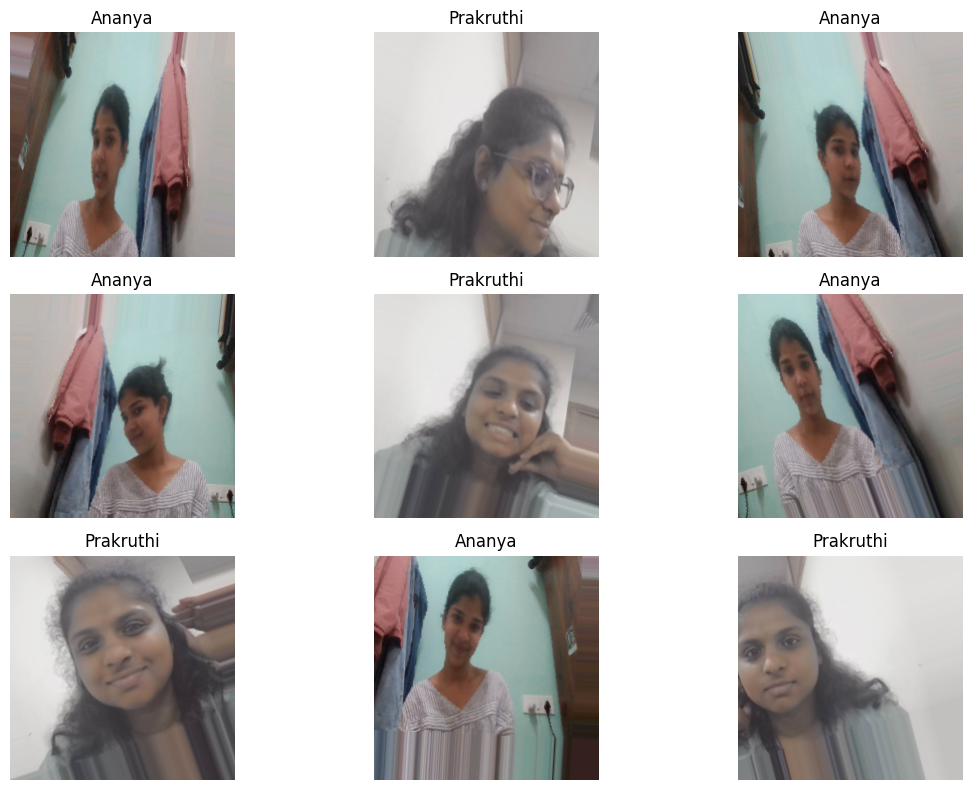

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(512, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,207,362 (12.24 MB)

 Trainable params: 3,207,362 (12.24 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 64s 11s/step - accuracy: 0.4770 - loss: 0.8447 - val_accuracy: 0.5000 - val_loss: 0.6921
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - accuracy: 0.5057 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss: 0.6849
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - accuracy: 0.5057 - loss: 0.6621 - val_accuracy: 0.5000 - val_loss: 0.6885
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - accuracy: 0.7241 - loss: 0.4861 - val_accuracy: 1.0000 - val_loss: 0.3280
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - accuracy: 0.9885 - loss: 0.2969 - val_accuracy: 1.0000 - val_loss: 0.1991
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - accuracy: 1.0000 - loss: 0.0814 - val_accuracy: 1.0000 - val_loss: 5.9831e-06
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 37s 6s/step - accuracy: 1.0000 - loss: 3.2302e-06 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 31s 5s/step - accuracy: 0.9080 - loss: 11.8312 - val_accuracy: 1.0000 - val_loss: 1

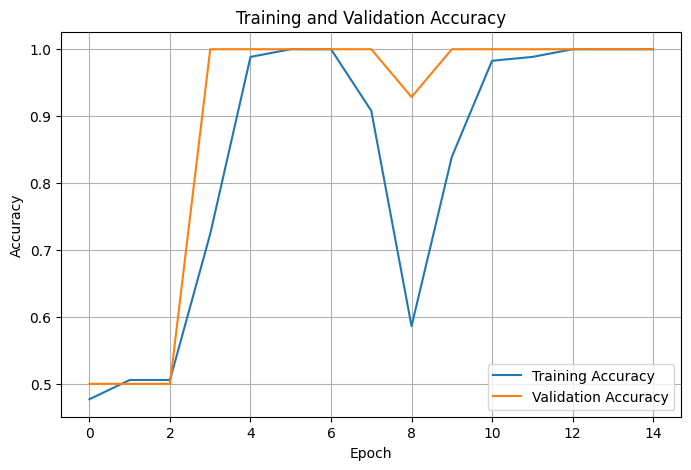

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [ ]:
model.save('FaceDetectionUsingCNN.h5')

print("Model saved successfully.")

Model saved successfully.


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('FaceDetectionUsingCNN.h5')

print("Model Loaded")

Model Loaded


In [ ]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 330ms/step - accuracy: 0.5000 - loss: 0.6988
Validation Loss: 0.6988334655761719
Validation Accuracy: 0.5


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 408ms/step


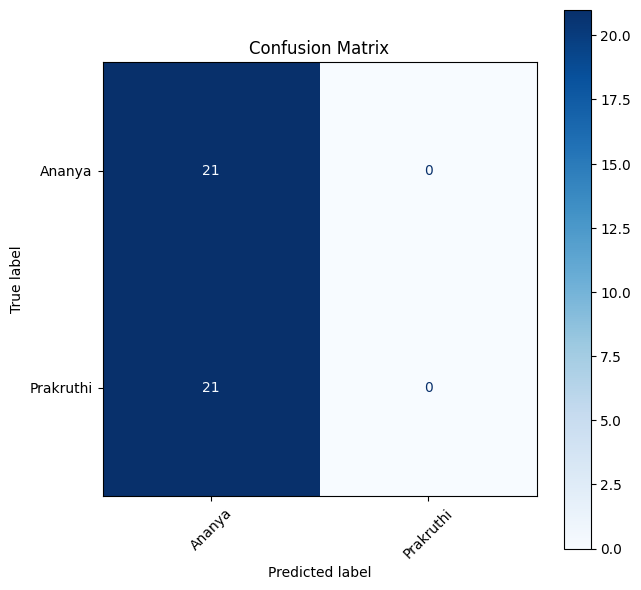

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

val_generator.reset()

predictions = model.predict(val_generator)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    ax=ax,
    cmap='Blues',
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

# Get uploaded filename
test_image_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(
    test_image_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

# Convert image to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Normalize
img_array = img_array / 255.0

# Prediction
prediction = model.predict(img_array)

# Get predicted class
ind = np.argmax(prediction[0])

predicted_class = class_names[ind]
confidence = prediction[0][ind] * 100

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

In [ ]:
print("\nClass Probabilities:")

for i, class_name in enumerate(class_names):
    print(
        f"{class_name}: {prediction[0][i] * 100:.2f}%"
    )